# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

1. Importação e Exploração (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


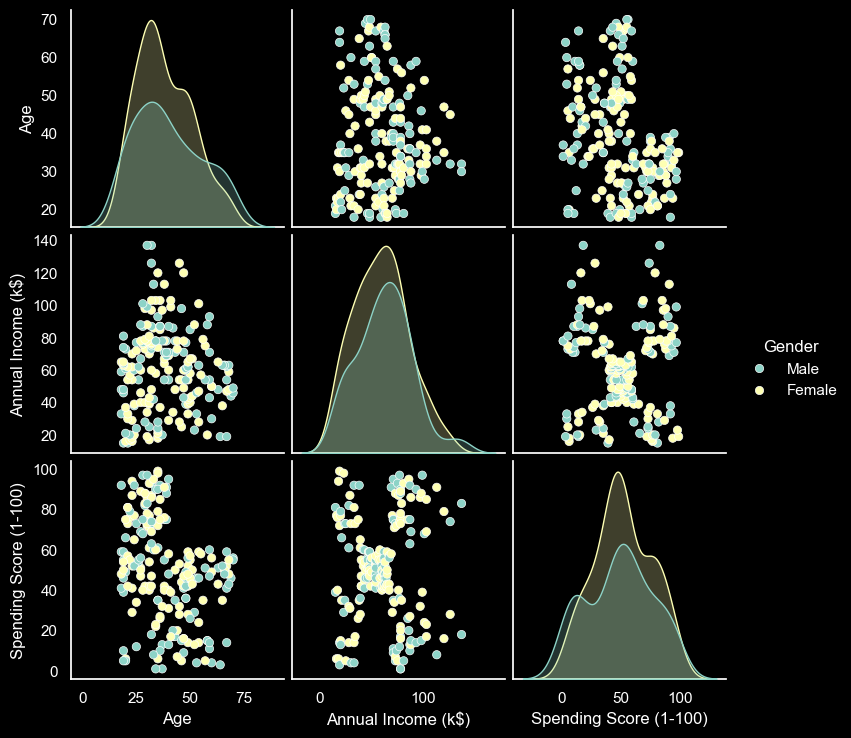

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Carregar o dataset
df = pd.read_csv('Mall_Customers.csv')

# Visualização inicial
print(df.info())
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender')
plt.show()

Antes de olharmos para o dinheiro, vamos olhar para as pessoas. Vamos ver a distribuição de gênero e idade dos clientes.

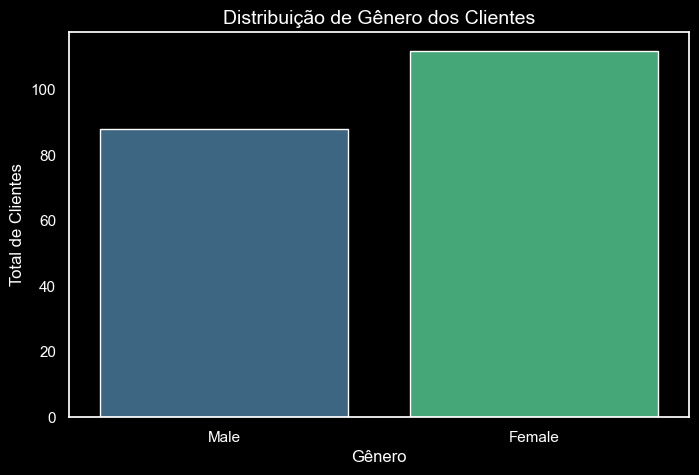

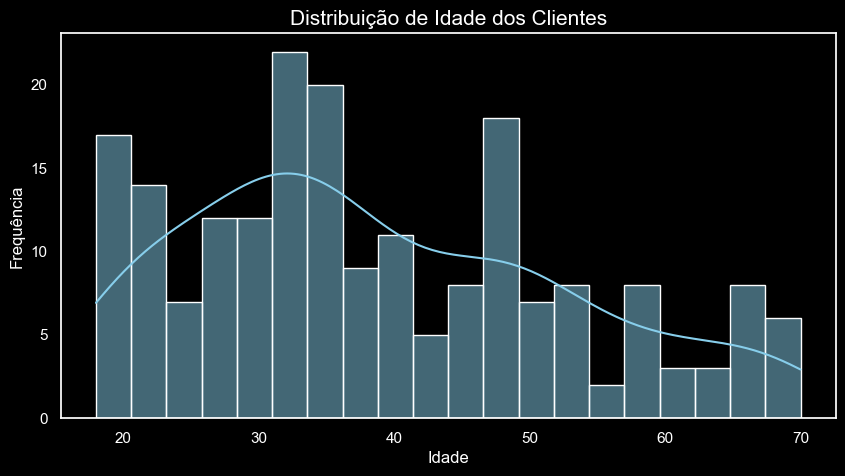

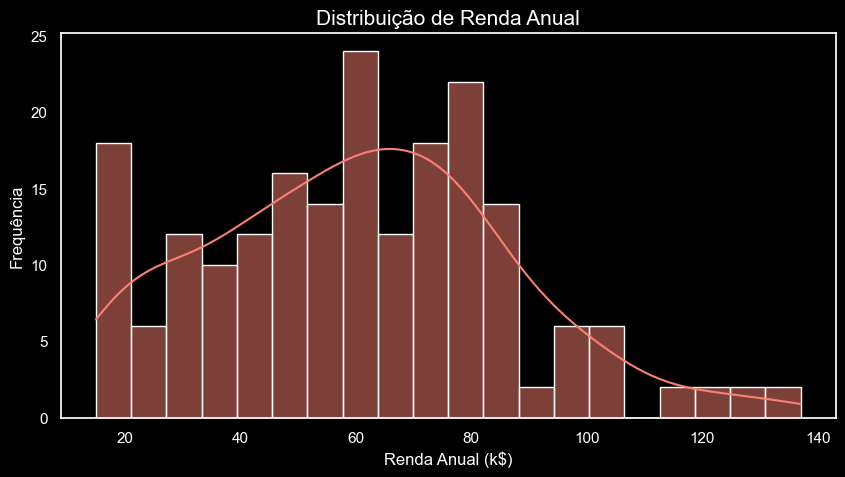

Genero
Female    112
Male       88
Name: count, dtype: int64


In [123]:
# Padronizando os nomes das colunas (removendo espaços e caracteres especiais)
df.columns = ['ID', 'Genero', 'Idade', 'Renda_Anual', 'Pontuacao_Gastos']

# 1. Distribuição de Gênero
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Genero', palette='viridis', hue='Genero', legend=False)
plt.title('Distribuição de Gênero dos Clientes', fontsize=14)
plt.xlabel('Gênero')
plt.ylabel('Total de Clientes')
plt.show()

# 2. Distribuição de Idade
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Idade', bins=20, kde=True, color='skyblue')
plt.title('Distribuição de Idade dos Clientes', fontsize=15)
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

# 3. Distribuição de Renda
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Renda_Anual', bins=20, kde=True, color='salmon')
plt.title('Distribuição de Renda Anual', fontsize=15)
plt.xlabel('Renda Anual (k$)')
plt.ylabel('Frequência')
plt.show()

# Imprimindo a contagem real
print(df['Genero'].value_counts())

# 2. Tratamento de Dados

In [124]:
# 1. Renomeando para facilitar a manipulação e evitar erros de sintaxe
df = df.rename(columns={
    'Gender': 'Genero',
    'Age': 'Idade',
    'Annual Income (k$)': 'Renda_Anual',
    'Spending Score (1-100)': 'Pontuacao_Gastos'
})

# 2. Criando uma cópia para o modelo e removendo o ID
df_modelo = df.drop('ID', axis=1, errors='ignore')

# 3. Encoding: Transformando Gênero em numérico antes do StandardScaler
df_modelo['Genero'] = df_modelo['Genero'].map({'Female': 1, 'Male': 0, 'Feminino': 1, 'Masculino': 0})

# 4. Padronização (Scaling)
scaler = StandardScaler()
df_scaled_data = scaler.fit_transform(df_modelo)

# Convertendo de volta para DataFrame apenas para conferência
df_scaled = pd.DataFrame(df_scaled_data, columns=df_modelo.columns)

print("Dados tratados e prontos para o K-Means:")
df_scaled.head()

Dados tratados e prontos para o K-Means:


,Genero,Idade,Renda_Anual,Pontuacao_Gastos
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


In [125]:
# Inicializando o escalonador
scaler = StandardScaler()

# Ajustando e transformando os dados
df_scaled = scaler.fit_transform(df_modelo)

# Convertendo de volta para um DataFrame para facilitar a visualização (opcional)
df_scaled = pd.DataFrame(df_scaled, columns=df_modelo.columns)

print("\nDados Padronizados (Prontos para o K-Means):")
print(df_scaled.head())


Dados Padronizados (Prontos para o K-Means):
     Genero     Idade  Renda_Anual  Pontuacao_Gastos
0 -1.128152 -1.424569    -1.738999         -0.434801
1 -1.128152 -1.281035    -1.738999          1.195704
2  0.886405 -1.352802    -1.700830         -1.715913
3  0.886405 -1.137502    -1.700830          1.040418
4  0.886405 -0.563369    -1.662660         -0.395980


# 3. Método do cotovelo para determinar o número ideal de clusters

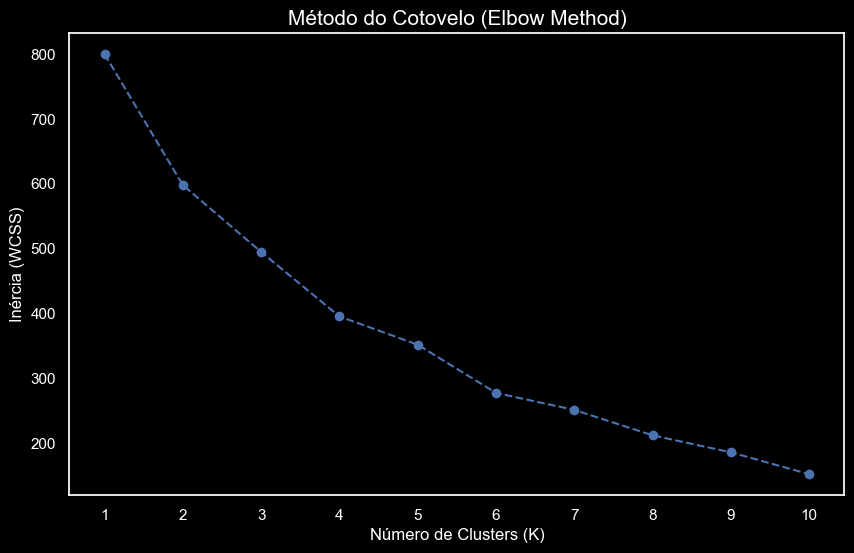

In [126]:
# Lista para armazenar o WCSS (Within-Cluster Sum of Square)
wcss = []

# Testando diferentes valores de K
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotando o Gráfico do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Método do Cotovelo (Elbow Method)', fontsize=15)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.xticks(range(1, 11))
plt.show()

# 4. Aplicando o K-Means com o número ideal de clusters

In [127]:
# Definindo o número de clusters baseado no gráfico
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)

# Treinando e prevendo os grupos
clusters = kmeans_final.fit_predict(df_scaled)

# Adicionando os resultados ao DataFrame original
df['Cluster'] = clusters

# 5. Avaliação dos Clusters

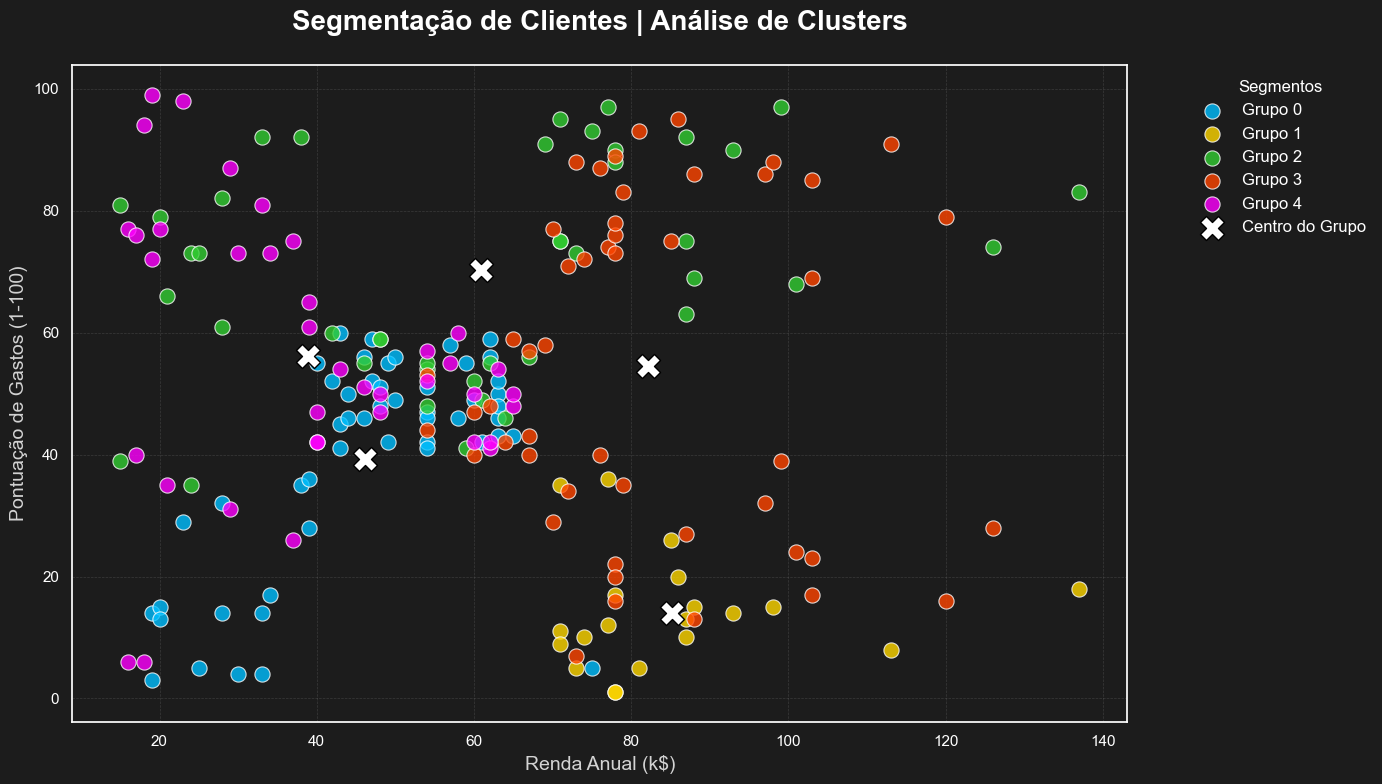

In [128]:
# 1. Configurando o tema escuro para máximo contraste
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 8)

# 2. Definindo cores
cores_vibrantes = ["#00BFFF", "#FFD700", "#32CD32", "#FF4500", "#FF00FF"]

# 3. Criando o gráfico
fig, ax = plt.subplots()
fig.patch.set_facecolor('#1c1c1c') # Fundo grafite profundo
ax.set_facecolor('#1c1c1c')

# 4.Scatter plo
for i, color in enumerate(cores_vibrantes):
    dados_cluster = df[df['Cluster'] == i]
    plt.scatter(
        dados_cluster['Renda_Anual'],
        dados_cluster['Pontuacao_Gastos'],
        s=120,
        c=color,
        label=f'Grupo {i}',
        alpha=0.8,
        edgecolors='white',
        linewidths=0.8
    )

#5. centroids
centroids = df.groupby('Cluster')[['Renda_Anual', 'Pontuacao_Gastos']].mean()
plt.scatter(
    centroids['Renda_Anual'],
    centroids['Pontuacao_Gastos'],
    marker='X',
    s=300,
    c='white',
    edgecolors='black',
    label='Centro do Grupo'
)

# 6. Estilização de Títulos e Eixos
plt.title('Segmentação de Clientes | Análise de Clusters', fontsize=20, color='white', pad=25, fontweight='bold')
plt.xlabel('Renda Anual (k$)', fontsize=14, color='lightgray')
plt.ylabel('Pontuação de Gastos (1-100)', fontsize=14, color='lightgray')

# 7. Grid bem sutil para ajudar na leitura dos eixos
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Legenda fora do gráfico
plt.legend(title="Segmentos", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

# 6. Avaliação do Silhouette Score

In [129]:
# Calculando o score (varia de -1 a 1, quanto mais perto de 1, melhor)
score = silhouette_score(df_scaled, clusters)
print(f"Coeficiente de Silhueta: {score:.3f}")

Coeficiente de Silhueta: 0.272


# 7. Interpretação dos Clusters

In [130]:
# Analisando as médias de cada cluster
resumo = df.groupby('Cluster')[['Idade', 'Renda_Anual', 'Pontuacao_Gastos']].mean().round(2)
resumo['Quantidade'] = df['Cluster'].value_counts()
print(resumo)

         Idade  Renda_Anual  Pontuacao_Gastos  Quantidade
Cluster                                                  
0        56.47        46.10             39.31          51
1        39.50        85.15             14.05          20
2        28.69        60.90             70.24          42
3        37.90        82.12             54.45          49
4        27.32        38.84             56.21          38


# 8. Interpretação dos Resultados e Aplicações Práticas

Cluster 0: Público maduro, possivelmente aposentados, com renda estável e gastos moderados.
Estratégia: Focar em serviços personalizados e fidelização para manter o engajamento.

Cluster 1: Alto poder aquisitivo, porém com baixa frequência de gastos no shopping.
Estratégia: Campanhas exclusivas e ofertas personalizadas para incentivar o consumo.

Cluster 2: Público jovem (estudantes/profissionais) com renda média e alto volume de compras.
Estratégia: Promoções e eventos interativos voltados a experiências de marca.

Cluster 3: Público premium com alta renda e alto padrão de gastos recorrentes.
Estratégia: Networking, serviços personalizados e acesso antecipado a lançamentos.

Cluster 4: Jovens com renda menor que priorizam gastos no shopping.
Estratégia: Focar em descontos e lançamentos de produtos de alta tendência.

A segmentação atingiu um resultado sólido, com um Silhouette Score de 0.272 indicando um padrão de comportamento distinto entre os clusters. A análise nos permitiu transformar dados brutos em insights acionáveis de 5 personas distintas, cada uma com características e necessidades únicas.

Com isso, podemos direcionar estratégias de marketing personalizadas para cada grupo, aumentando a eficácia das campanhas e otimizando o retorno sobre o investimento (ROI).